# Gibbs Replication (NeurIPS 2015)

This notebook implements the **Gibbs-sampler experiments** from:

- Gotovos, Hassani, Krause (2015), *Sampling from Probabilistic Submodular Models*
- using the model definitions/conditioning setup referenced from Djolonga & Krause (NeurIPS 2014).

Important reproducibility notes:

- Facility-location in the original setup uses a real water-network influence matrix `W` from [22].
- The original repository/data package is not publicly accessible anymore; this notebook therefore supports two modes:
  - real matrix mode (if you have the original file),
  - a structured synthetic proxy that mirrors the published setup dimensions (`100` candidate locations, `500` contamination scenarios) and then follows the same subsampling/inference pipeline.
- Facility conditioning in [6] uses a modular upper bound `m`; this notebook uses the valid singleton upper bound `m_i = F({i})`.
- The 2015 paper states "multiple repetitions" but does not print the exact count. This notebook defaults to `30`, and you can override it.


In [15]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Sequence

import matplotlib.pyplot as plt
import numpy as np


In [16]:
# --- User-configurable settings ---

FACILITY_MATRIX_PATH = Path('data/facility_w22_matrix.npy')

# Options: 'real_if_available', 'real_only', 'synthetic_proxy'
FACILITY_DATA_MODE = 'real_if_available'

# Full matrix dimensions used in the 2014/2015 facility setup.
FACILITY_FULL_NUM_LOCATIONS = 100
FACILITY_NUM_SCENARIOS = 500

# 2015 paper uses "multiple repetitions" (exact count not printed in the main text).
NUM_REPS = 30

ITER_COUNTS = (100, 500, 2000)

# Ground-set size fixed in the 2015 Gibbs experiment.
N = 20

RNG_SEED = 0


def load_facility_matrix(path: Path) -> np.ndarray:
    """Load a facility-location influence matrix W (locations x scenarios)."""
    if not path.exists():
        raise FileNotFoundError(
            f'Missing facility matrix at {path}. '
            'Provide the [locations x scenarios] matrix from the original water-network setup in [22].'
        )

    suffix = path.suffix.lower()
    if suffix == '.npy':
        W = np.load(path)
    elif suffix == '.npz':
        z = np.load(path)
        if 'W' in z.files:
            W = z['W']
        elif z.files:
            W = z[z.files[0]]
        else:
            raise ValueError(f'No arrays found in {path}')
    elif suffix in ('.csv', '.txt'):
        W = np.loadtxt(path, delimiter=',' if suffix == '.csv' else None)
    else:
        raise ValueError(f'Unsupported facility matrix format: {path}')

    W = np.asarray(W, dtype=np.float64)
    if W.ndim != 2:
        raise ValueError(f'Expected a 2D matrix, got shape {W.shape}')
    if W.shape[0] < N:
        raise ValueError(f'Need at least {N} locations, got {W.shape[0]}')
    if W.shape[1] < 1:
        raise ValueError('Need at least one scenario column')
    return W


In [17]:
@dataclass
class ProbModel:
    name: str
    n: int
    energy: Callable[[np.ndarray], float]
    delta: Callable[[np.ndarray, int], float]
    energy_batch: Callable[[np.ndarray], np.ndarray]
    metadata: Dict[str, np.ndarray]


def sigmoid(x: float) -> float:
    x = float(np.clip(x, -60.0, 60.0))
    return 1.0 / (1.0 + np.exp(-x))


def _normalize_fixed(n: int, fixed_one=(), fixed_zero=()):
    one = np.array(sorted(set(int(i) for i in fixed_one)), dtype=int)
    zero = np.array(sorted(set(int(i) for i in fixed_zero)), dtype=int)
    if np.intersect1d(one, zero).size > 0:
        raise ValueError('fixed_one and fixed_zero overlap')
    fixed = set(one.tolist()) | set(zero.tolist())
    free = np.array([i for i in range(n) if i not in fixed], dtype=int)
    return one, zero, free


def gibbs_sampler(
    model: ProbModel,
    num_iters: int,
    rng: np.random.Generator,
    fixed_one=(),
    fixed_zero=(),
    x0: np.ndarray | None = None,
) -> np.ndarray:
    """Algorithm 1 in the NeurIPS 2015 paper."""
    n = model.n
    one, zero, free = _normalize_fixed(n, fixed_one=fixed_one, fixed_zero=fixed_zero)

    x = np.zeros(n, dtype=np.int8)
    x[one] = 1

    if x0 is None:
        if free.size > 0:
            x[free] = rng.integers(0, 2, size=free.size, dtype=np.int8)
    else:
        x = np.array(x0, dtype=np.int8, copy=True)
        x[one] = 1
        x[zero] = 0

    trace = np.empty((num_iters, n), dtype=np.int8)

    if free.size == 0:
        trace[:] = x
        return trace

    for t in range(num_iters):
        i = int(free[rng.integers(0, free.size)])
        d = model.delta(x, i)
        p_add = sigmoid(d)
        x[i] = 1 if rng.random() < p_add else 0
        trace[t] = x

    return trace


def marginal_estimate(trace: np.ndarray, iters: int) -> np.ndarray:
    burn = iters // 2
    return trace[burn:iters].mean(axis=0)


def exact_marginals(model: ProbModel, fixed_one=(), fixed_zero=()) -> np.ndarray:
    n = model.n
    one, zero, free = _normalize_fixed(n, fixed_one=fixed_one, fixed_zero=fixed_zero)
    m = free.size

    if m == 0:
        out = np.zeros(n, dtype=np.float64)
        out[one] = 1.0
        out[zero] = 0.0
        return out

    states = np.arange(1 << m, dtype=np.uint32)
    bits = ((states[:, None] >> np.arange(m, dtype=np.uint32)) & 1).astype(np.int8)

    X = np.zeros((states.size, n), dtype=np.int8)
    if one.size > 0:
        X[:, one] = 1
    X[:, free] = bits

    e = model.energy_batch(X)
    e = e - np.max(e)
    w = np.exp(e)
    p = w / np.sum(w)

    marg = np.asarray(X.T @ p, dtype=np.float64)
    if one.size > 0:
        marg[one] = 1.0
    if zero.size > 0:
        marg[zero] = 0.0
    return marg


In [18]:
# --- Facility-location model (submodular + modular penalty) ---
# F_fac(A) = sum_j max_{i in A} W_ij
# p(A) propto exp(F_fac(A) - lambda * |A|), lambda = 2


def _connected_components(adj: np.ndarray) -> list[np.ndarray]:
    n = adj.shape[0]
    unvisited = np.ones(n, dtype=bool)
    comps: list[np.ndarray] = []

    for start in np.flatnonzero(unvisited):
        stack = [int(start)]
        unvisited[start] = False
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.flatnonzero(adj[u] & unvisited)
            if nbrs.size > 0:
                unvisited[nbrs] = False
                stack.extend(nbrs.tolist())
        comps.append(np.asarray(comp, dtype=int))

    return comps


def build_surrogate_facility_matrix(
    num_locations: int,
    num_scenarios: int,
    rng: np.random.Generator,
    knn: int = 4,
) -> np.ndarray:
    """
    Build a structured proxy for the missing [22] water-network matrix.

    Design choices to stay close to the published setup:
    - 100 candidate locations, 500 contamination scenarios (configurable)
    - contamination influence decays with shortest-path distance on a sparse network
    - each column is a scenario, each row is a candidate sensor location
    """
    if knn < 1:
        raise ValueError('knn must be >= 1')

    # Candidate sensor locations on a latent 2D manifold.
    points = rng.uniform(0.0, 1.0, size=(num_locations, 2))
    euclid = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=-1)

    # Sparse undirected network: symmetric kNN graph.
    idx = np.argsort(euclid, axis=1)
    adj = np.zeros((num_locations, num_locations), dtype=bool)
    for i in range(num_locations):
        nbrs = idx[i, 1:knn + 1]
        adj[i, nbrs] = True
    adj = adj | adj.T
    np.fill_diagonal(adj, False)

    # Ensure connectedness by linking nearest cross-component pairs.
    comps = _connected_components(adj)
    while len(comps) > 1:
        c0 = comps[0]
        best = None
        best_pair = None
        best_comp_idx = None
        for ci in range(1, len(comps)):
            c1 = comps[ci]
            block = euclid[np.ix_(c0, c1)]
            flat = int(np.argmin(block))
            i0, i1 = np.unravel_index(flat, block.shape)
            d = float(block[i0, i1])
            if best is None or d < best:
                best = d
                best_pair = (int(c0[i0]), int(c1[i1]))
                best_comp_idx = ci

        assert best_pair is not None and best_comp_idx is not None
        u, v = best_pair
        adj[u, v] = True
        adj[v, u] = True

        merged = np.concatenate([c0, comps[best_comp_idx]])
        comps = [merged] + [comps[i] for i in range(1, len(comps)) if i != best_comp_idx]

    # Edge lengths and all-pairs shortest paths (Floyd-Warshall, vectorized inner updates).
    dist = np.full((num_locations, num_locations), np.inf, dtype=np.float64)
    np.fill_diagonal(dist, 0.0)

    ii, jj = np.where(np.triu(adj, k=1))
    scales = 0.85 + 0.30 * rng.random(ii.size)
    lengths = euclid[ii, jj] * scales
    dist[ii, jj] = lengths
    dist[jj, ii] = lengths

    for k in range(num_locations):
        dist = np.minimum(dist, dist[:, [k]] + dist[[k], :])

    finite = dist[np.isfinite(dist) & (dist > 0.0)]
    base_scale = float(np.median(finite)) if finite.size > 0 else 1.0

    # Scenario-wise contamination influence profile.
    sources = rng.integers(0, num_locations, size=num_scenarios)
    taus = rng.uniform(0.7, 1.6, size=num_scenarios) * base_scale

    W = np.empty((num_locations, num_scenarios), dtype=np.float64)
    for s in range(num_scenarios):
        src = int(sources[s])
        col = np.exp(-dist[:, src] / max(taus[s], 1e-12))
        col *= rng.lognormal(mean=0.0, sigma=0.15, size=num_locations)
        col = np.clip(col, 0.0, None)

        cmax = float(col.max())
        if cmax > 0.0:
            col /= cmax

        W[:, s] = col

    return W


def resolve_facility_matrix(
    path: Path,
    mode: str,
    rng: np.random.Generator,
    full_num_locations: int = FACILITY_FULL_NUM_LOCATIONS,
    full_num_scenarios: int = FACILITY_NUM_SCENARIOS,
) -> tuple[np.ndarray, str]:
    """Return (W_full, source_description) according to the selected data mode."""
    mode = mode.lower()
    valid = {'real_if_available', 'real_only', 'synthetic_proxy'}
    if mode not in valid:
        raise ValueError(f'FACILITY_DATA_MODE must be one of {sorted(valid)}, got: {mode}')

    if mode in {'real_if_available', 'real_only'} and path.exists():
        W = load_facility_matrix(path)
        return W, f'real_file:{path}'

    if mode == 'real_only':
        raise FileNotFoundError(
            f'FACILITY_DATA_MODE=real_only but matrix file was not found: {path}'
        )

    W = build_surrogate_facility_matrix(
        num_locations=full_num_locations,
        num_scenarios=full_num_scenarios,
        rng=rng,
    )
    return W, f'synthetic_proxy:{full_num_locations}x{full_num_scenarios}'


def subsample_facility_matrix(
    W_full: np.ndarray,
    n_locations: int,
    n_scenarios: int,
    rng: np.random.Generator,
) -> np.ndarray:
    L, S = W_full.shape
    if L < n_locations:
        raise ValueError(f'Need at least {n_locations} locations, got {L}')

    loc_idx = rng.choice(L, size=n_locations, replace=False)
    if S >= n_scenarios:
        sc_idx = rng.choice(S, size=n_scenarios, replace=False)
    else:
        sc_idx = np.arange(S)

    return np.asarray(W_full[np.ix_(loc_idx, sc_idx)], dtype=np.float64)


def make_facility_model(W: np.ndarray, penalty: float = 2.0) -> ProbModel:
    W = np.asarray(W, dtype=np.float64)
    n, m = W.shape

    def energy(x: np.ndarray) -> float:
        sel = x.astype(bool, copy=False)
        if np.any(sel):
            f = W[sel].max(axis=0).sum()
        else:
            f = 0.0
        return float(f - penalty * sel.sum())

    def delta(x: np.ndarray, i: int) -> float:
        x_add = np.array(x, copy=True)
        x_rem = np.array(x, copy=True)
        x_add[i] = 1
        x_rem[i] = 0
        return float(energy(x_add) - energy(x_rem))

    def energy_batch(X: np.ndarray) -> np.ndarray:
        Xb = X.astype(np.int8, copy=False)
        B = Xb.shape[0]
        max_vals = np.zeros((B, m), dtype=np.float64)
        for i in range(n):
            mask = Xb[:, i].astype(bool)
            if np.any(mask):
                max_vals[mask] = np.maximum(max_vals[mask], W[i])
        return max_vals.sum(axis=1) - penalty * Xb.sum(axis=1)

    return ProbModel(
        name='Facility location',
        n=n,
        energy=energy,
        delta=delta,
        energy_batch=energy_batch,
        metadata={'W': W, 'penalty': np.array([penalty])},
    )


def facility_singleton_upper_bound(W: np.ndarray) -> np.ndarray:
    """A valid modular upper bound for normalized monotone facility F: m_i = F({i})."""
    return np.asarray(W, dtype=np.float64).sum(axis=1)


In [19]:
# --- Pairwise MRF model ---
# F_pair(A) = sum_{i in A, j notin A} exp(-||x_i - x_j||)


def make_pairwise_model(
    n: int = 20,
    rng: np.random.Generator | None = None,
) -> ProbModel:
    if rng is None:
        rng = np.random.default_rng()

    if n % 2 != 0:
        raise ValueError('n must be even for the two-cluster setup')

    n0 = n // 2
    n1 = n - n0

    c0 = rng.multivariate_normal(mean=[3.0, 3.0], cov=np.eye(2), size=n0)
    c1 = rng.multivariate_normal(mean=[-3.0, -3.0], cov=np.eye(2), size=n1)
    points = np.vstack([c0, c1])
    labels = np.array([0] * n0 + [1] * n1, dtype=np.int8)

    dists = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=-1)
    W = np.exp(-dists)
    np.fill_diagonal(W, 0.0)

    def energy(x: np.ndarray) -> float:
        xf = x.astype(np.float64, copy=False)
        return float(xf @ W @ (1.0 - xf))

    def delta(x: np.ndarray, i: int) -> float:
        xf = x.astype(np.float64, copy=False)
        return float(np.sum((1.0 - 2.0 * xf) * W[i]))

    def energy_batch(X: np.ndarray) -> np.ndarray:
        Xf = X.astype(np.float64, copy=False)
        return np.einsum('bi,ij,bj->b', Xf, W, 1.0 - Xf, optimize=True)

    return ProbModel(
        name='Pairwise MRF',
        n=n,
        energy=energy,
        delta=delta,
        energy_batch=energy_batch,
        metadata={'W': W, 'points': points, 'labels': labels},
    )


In [20]:
# --- Higher-order MRF model ---
# Prior from decomposable potentials over neighborhoods of a Watts-Strogatz graph.
# Observation model: noisy node observations (fp/fn) of a cascade-generated active set.


def watts_strogatz_adjacency(
    n: int,
    k: int,
    rewire_p: float,
    rng: np.random.Generator,
) -> np.ndarray:
    if k % 2 != 0:
        raise ValueError('k must be even')
    if not (0 <= rewire_p <= 1):
        raise ValueError('rewire_p must be in [0, 1]')
    if k >= n:
        raise ValueError('k must be < n')

    adj = np.zeros((n, n), dtype=bool)
    half = k // 2

    for i in range(n):
        for d in range(1, half + 1):
            j = (i + d) % n
            adj[i, j] = True
            adj[j, i] = True

    for i in range(n):
        for d in range(1, half + 1):
            j = (i + d) % n
            if i < j and rng.random() < rewire_p:
                adj[i, j] = False
                adj[j, i] = False

                candidates = np.flatnonzero(~adj[i])
                candidates = candidates[candidates != i]
                new_j = int(rng.choice(candidates))

                adj[i, new_j] = True
                adj[new_j, i] = True

    return adj


def independent_cascade(
    adj: np.ndarray,
    source: int,
    activation_prob: float,
    rng: np.random.Generator,
) -> np.ndarray:
    n = adj.shape[0]
    active = np.zeros(n, dtype=bool)
    active[source] = True
    frontier = [source]

    while frontier:
        new_frontier = []
        for u in frontier:
            neighbors = np.flatnonzero(adj[u])
            for v in neighbors:
                if not active[v] and rng.random() < activation_prob:
                    active[v] = True
                    new_frontier.append(int(v))
        frontier = new_frontier

    return active


def noisy_observation(
    active: np.ndarray,
    p_false_positive: float,
    p_false_negative: float,
    rng: np.random.Generator,
) -> np.ndarray:
    n = active.size
    obs = np.zeros(n, dtype=bool)

    on_idx = np.flatnonzero(active)
    off_idx = np.flatnonzero(~active)

    if on_idx.size > 0:
        obs[on_idx] = rng.random(on_idx.size) < (1.0 - p_false_negative)
    if off_idx.size > 0:
        obs[off_idx] = rng.random(off_idx.size) < p_false_positive

    return obs


def _pow_fraction(frac: np.ndarray, exponent: float) -> np.ndarray:
    if exponent == 0.0:
        return (frac > 0.0).astype(np.float64)
    out = np.zeros_like(frac, dtype=np.float64)
    mask = frac > 0.0
    out[mask] = np.power(frac[mask], exponent)
    return out


def make_higher_order_posterior_model(
    adj: np.ndarray,
    mu: float,
    observed: np.ndarray,
    p_false_positive: float = 0.1,
    p_false_negative: float = 0.3,
) -> ProbModel:
    n = adj.shape[0]
    observed = np.asarray(observed, dtype=bool)
    if observed.shape != (n,):
        raise ValueError('observed must be shape (n,)')

    if not (0.0 <= mu <= 1.0):
        raise ValueError('mu must be in [0, 1]')

    # 2015 statement: mu=0 modular, mu->1 strongly supermodular.
    exponent = 1.0 - float(mu)

    neigh = adj.copy()
    np.fill_diagonal(neigh, True)
    deg = neigh.sum(axis=1).astype(np.float64)

    # Modular likelihood coefficients from noisy observations N.
    coeff = np.where(
        observed,
        np.log(1.0 - p_false_negative) - np.log(p_false_positive),
        np.log(p_false_negative) - np.log(1.0 - p_false_positive),
    ).astype(np.float64)

    affected = [np.flatnonzero(neigh[:, i]) for i in range(n)]
    neigh_i = [neigh[:, i].astype(np.int8) for i in range(n)]

    def energy(x: np.ndarray) -> float:
        xf = x.astype(np.int8, copy=False)
        counts = neigh @ xf
        frac = counts.astype(np.float64) / deg
        prior = -np.sum(_pow_fraction(frac, exponent))
        like = float(coeff @ xf)
        return float(prior + like)

    def delta(x: np.ndarray, i: int) -> float:
        xf = x.astype(np.int8, copy=False)
        counts = neigh @ xf

        xi = int(xf[i])
        counts0 = counts - xi * neigh_i[i]

        idx = affected[i]
        c0 = counts0[idx].astype(np.float64)
        d = deg[idx]

        frac0 = c0 / d
        frac1 = (c0 + 1.0) / d
        d_prior = -np.sum(_pow_fraction(frac1, exponent) - _pow_fraction(frac0, exponent))

        return float(d_prior + coeff[i])

    def energy_batch(X: np.ndarray) -> np.ndarray:
        Xf = X.astype(np.float64, copy=False)
        counts = Xf @ neigh.T.astype(np.float64)
        frac = counts / deg[None, :]
        prior = -np.sum(_pow_fraction(frac, exponent), axis=1)
        like = Xf @ coeff
        return prior + like

    return ProbModel(
        name=f'Higher-order MRF (mu={mu:.2f})',
        n=n,
        energy=energy,
        delta=delta,
        energy_batch=energy_batch,
        metadata={
            'adjacency': adj,
            'observed': observed.astype(np.int8),
            'mu': np.array([mu], dtype=np.float64),
            'coeff': coeff,
        },
    )


In [21]:
def _init_error_table(x_values: Sequence[float], iter_counts: Sequence[int]):
    return {it: {float(x): [] for x in x_values} for it in iter_counts}


def _append_errors(table, x_value, iter_counts, trace, exact):
    xk = float(x_value)
    for it in iter_counts:
        est = marginal_estimate(trace, it)
        err = float(np.mean(np.abs(est - exact)))
        table[it][xk].append(err)


def summarize_error_table(table):
    summary = {}
    for it, x_to_vals in table.items():
        xs = np.array(sorted(x_to_vals.keys()), dtype=np.float64)
        means = []
        stderrs = []
        for x in xs:
            vals = np.asarray(x_to_vals[x], dtype=np.float64)
            means.append(vals.mean())
            if vals.size > 1:
                stderrs.append(vals.std(ddof=1) / np.sqrt(vals.size))
            else:
                stderrs.append(0.0)
        summary[it] = {
            'x': xs,
            'mean': np.asarray(means, dtype=np.float64),
            'stderr': np.asarray(stderrs, dtype=np.float64),
        }
    return summary


def run_facility_experiment(
    W_full: np.ndarray,
    num_reps: int = NUM_REPS,
    iter_counts: Sequence[int] = ITER_COUNTS,
    seed: int = RNG_SEED,
    n: int = N,
    n_scenarios: int = FACILITY_NUM_SCENARIOS,
    penalty: float = 2.0,
):
    rng = np.random.default_rng(seed)
    x_values = np.arange(0, n, 2, dtype=int)
    table = _init_error_table(x_values=x_values, iter_counts=iter_counts)
    max_iter = int(max(iter_counts))

    for _ in range(num_reps):
        W = subsample_facility_matrix(W_full, n_locations=n, n_scenarios=n_scenarios, rng=rng)
        model = make_facility_model(W=W, penalty=penalty)

        # Sampling strategy from [6]: q_i = 1 / (1 + exp(-m_i + lambda)).
        m = facility_singleton_upper_bound(W)
        q = 1.0 / (1.0 + np.exp(-(m - penalty)))

        order = rng.permutation(n)
        z = rng.random(n) < q

        for k in x_values:
            idx = order[:k]
            fixed_one = idx[z[idx]]
            fixed_zero = idx[~z[idx]]

            exact = exact_marginals(model, fixed_one=fixed_one, fixed_zero=fixed_zero)
            trace = gibbs_sampler(
                model,
                num_iters=max_iter,
                rng=rng,
                fixed_one=fixed_one,
                fixed_zero=fixed_zero,
            )
            _append_errors(table, k, iter_counts, trace, exact)

    return summarize_error_table(table)


def run_pairwise_experiment(
    num_reps: int = NUM_REPS,
    iter_counts: Sequence[int] = ITER_COUNTS,
    seed: int = RNG_SEED + 1,
    n: int = N,
):
    rng = np.random.default_rng(seed)
    x_values = np.arange(0, n // 2, dtype=int)
    table = _init_error_table(x_values=x_values, iter_counts=iter_counts)
    max_iter = int(max(iter_counts))

    for _ in range(num_reps):
        model = make_pairwise_model(n=n, rng=rng)
        labels = model.metadata['labels']

        cluster0 = np.flatnonzero(labels == 0)
        cluster1 = np.flatnonzero(labels == 1)
        order0 = rng.permutation(cluster0)
        order1 = rng.permutation(cluster1)

        for k in x_values:
            fixed_one = order0[:k]
            fixed_zero = order1[:k]

            exact = exact_marginals(model, fixed_one=fixed_one, fixed_zero=fixed_zero)
            trace = gibbs_sampler(
                model,
                num_iters=max_iter,
                rng=rng,
                fixed_one=fixed_one,
                fixed_zero=fixed_zero,
            )
            _append_errors(table, k, iter_counts, trace, exact)

    return summarize_error_table(table)


def run_higher_order_experiment(
    num_reps: int = NUM_REPS,
    iter_counts: Sequence[int] = ITER_COUNTS,
    seed: int = RNG_SEED + 2,
    n: int = N,
    ws_k: int = 6,
    ws_rewire: float = 0.5,
    cascade_activation_prob: float = 0.2,
    p_false_positive: float = 0.1,
    p_false_negative: float = 0.3,
    mu_values: Sequence[float] | None = None,
):
    if mu_values is None:
        mu_values = np.linspace(0.0, 1.0, 6)

    rng = np.random.default_rng(seed)
    x_values = np.asarray(list(mu_values), dtype=np.float64)
    table = _init_error_table(x_values=x_values, iter_counts=iter_counts)
    max_iter = int(max(iter_counts))

    for _ in range(num_reps):
        adj = watts_strogatz_adjacency(n=n, k=ws_k, rewire_p=ws_rewire, rng=rng)

        source = int(rng.integers(0, n))
        cascaded = independent_cascade(
            adj=adj,
            source=source,
            activation_prob=cascade_activation_prob,
            rng=rng,
        )
        observed = noisy_observation(
            active=cascaded,
            p_false_positive=p_false_positive,
            p_false_negative=p_false_negative,
            rng=rng,
        )

        for mu in x_values:
            model = make_higher_order_posterior_model(
                adj=adj,
                mu=float(mu),
                observed=observed,
                p_false_positive=p_false_positive,
                p_false_negative=p_false_negative,
            )
            exact = exact_marginals(model)
            trace = gibbs_sampler(model, num_iters=max_iter, rng=rng)
            _append_errors(table, float(mu), iter_counts, trace, exact)

    return summarize_error_table(table)


In [22]:
def plot_summary(ax, summary, title: str, xlabel: str):
    colors = {
        100: '#E76F51',
        500: '#2A9D8F',
        2000: '#264653',
    }

    for it in sorted(summary.keys()):
        s = summary[it]
        ax.errorbar(
            s['x'],
            s['mean'],
            yerr=2.0 * s['stderr'],
            marker='o',
            capsize=3,
            linewidth=1.7,
            markersize=4,
            label=f'Gibbs ({it})',
            color=colors.get(it),
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Absolute error')
    ax.grid(alpha=0.25)


In [23]:
# Runtime note:
# This is intentionally expensive (exact marginals by enumeration at n=20).

facility_rng = np.random.default_rng(RNG_SEED + 10_000)
W_FULL, FACILITY_SOURCE = resolve_facility_matrix(
    path=FACILITY_MATRIX_PATH,
    mode=FACILITY_DATA_MODE,
    rng=facility_rng,
    full_num_locations=FACILITY_FULL_NUM_LOCATIONS,
    full_num_scenarios=FACILITY_NUM_SCENARIOS,
)
print(f'Facility matrix source: {FACILITY_SOURCE}, shape={W_FULL.shape}')

facility_summary = run_facility_experiment(
    W_full=W_FULL,
    num_reps=NUM_REPS,
    iter_counts=ITER_COUNTS,
    seed=RNG_SEED,
)

pairwise_summary = run_pairwise_experiment(
    num_reps=NUM_REPS,
    iter_counts=ITER_COUNTS,
    seed=RNG_SEED + 1,
)

higher_summary = run_higher_order_experiment(
    num_reps=NUM_REPS,
    iter_counts=ITER_COUNTS,
    seed=RNG_SEED + 2,
)


Facility matrix source: synthetic_proxy:100x500, shape=(100, 500)


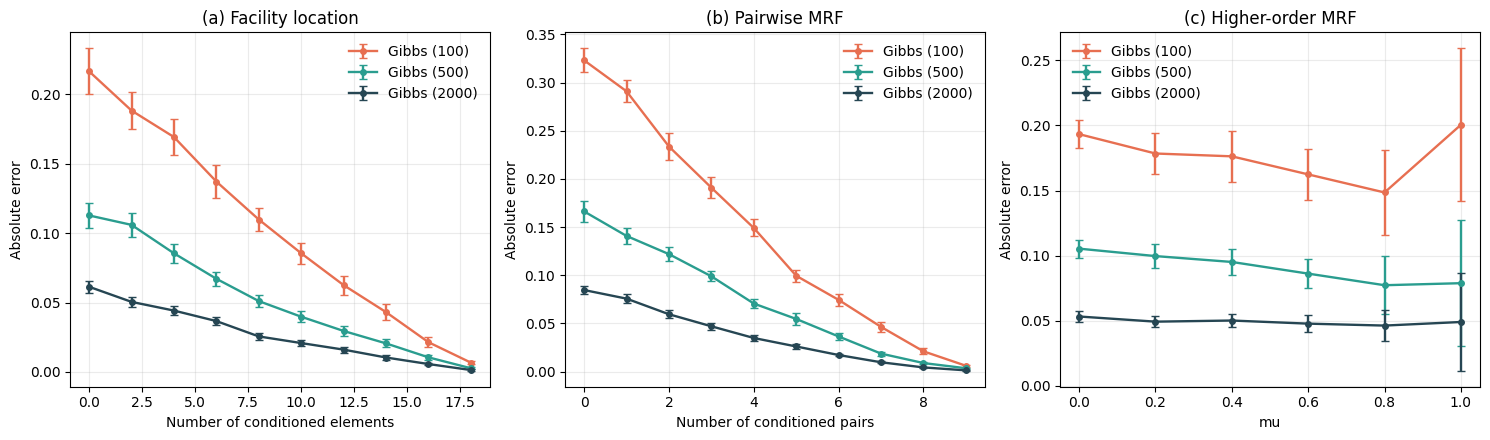

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

plot_summary(
    axes[0],
    facility_summary,
    title='(a) Facility location',
    xlabel='Number of conditioned elements',
)
plot_summary(
    axes[1],
    pairwise_summary,
    title='(b) Pairwise MRF',
    xlabel='Number of conditioned pairs',
)
plot_summary(
    axes[2],
    higher_summary,
    title='(c) Higher-order MRF',
    xlabel='mu',
)

for ax in axes:
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()
